# SLA Breach Analysis and Exploratory Data Analysis (EDA)

This notebook analyzes delivery performance and SLA breach patterns using the Olist ecommerce dataset.

Objectives:
- Understand delivery-related data
- Analyze SLA breach patterns
- Identify high-risk states, categories, and delivery conditions
- Visualize delivery delay trends

# Task 1 - Load and Inspect Dataset

In [3]:
import pandas as pd
df = pd.read_csv("../data/gold/olist_final_consumption_dataset.csv")

In [6]:
df.shape
df.head()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       112650 non-null  str    
 1   order_item_id                  112650 non-null  int64  
 2   product_id                     112650 non-null  str    
 3   seller_id                      112650 non-null  str    
 4   customer_id                    112650 non-null  str    
 5   order_status                   112650 non-null  str    
 6   order_purchase_timestamp       112650 non-null  str    
 7   order_approved_at              112635 non-null  str    
 8   order_delivered_carrier_date   111456 non-null  str    
 9   order_delivered_customer_date  110196 non-null  str    
 10  order_estimated_delivery_date  112650 non-null  str    
 11  purchase_dayofweek             112650 non-null  int64  
 12  purchase_hour                  112650 non

order_id                            0
order_item_id                       0
product_id                          0
seller_id                           0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
purchase_dayofweek                  0
purchase_hour                       0
approval_delay_hours               15
carrier_handover_days            1209
actual_delivery_days             2454
estimated_delivery_days             0
delivery_delay_days              2454
sla_breached                        0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
product_category_name               0
product_name

# Task 2 - SLA Related Column Analysis

The following analysis checks the availability and completeness of important SLA-related columns.

In [7]:
sla_columns = [
    'order_purchase_timestamp',
    'order_estimated_delivery_date',
    'order_delivered_customer_date',
    'order_status'
]

df[sla_columns].isnull().sum()

order_purchase_timestamp            0
order_estimated_delivery_date       0
order_delivered_customer_date    2454
order_status                        0
dtype: int64

# Task 3 - Basic Delivery Analysis

In [8]:
df['order_status'].value_counts()

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

In [9]:
delivered_df = df[df['order_status'] == 'delivered']

delivered_df.shape

(110197, 43)

In [10]:
df['order_estimated_delivery_date'].notnull().sum()

np.int64(112650)

# Task 4 - SLA Breach Pattern Analysis

In [12]:
df['sla_breached'].value_counts()

sla_breached
0    103935
1      8715
Name: count, dtype: int64

In [13]:
(df['sla_breached'].mean()) * 100

np.float64(7.736351531291612)

In [14]:
df.groupby('customer_state')['sla_breached'].mean().sort_values(ascending=False)

customer_state
AL    0.231982
MA    0.197816
SE    0.158442
PI    0.149446
CE    0.147497
BA    0.132666
RJ    0.125866
PA    0.121296
TO    0.120635
ES    0.120567
PB    0.109635
MS    0.107448
RN    0.102079
PE    0.098560
RR    0.096154
SC    0.094349
GO    0.076725
DF    0.072735
RS    0.067682
MT    0.066351
SP    0.056461
MG    0.053622
AP    0.048780
PR    0.047038
AM    0.042424
RO    0.039568
AC    0.032609
Name: sla_breached, dtype: float64

In [18]:
(
    df.groupby('customer_state')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).round(2)

customer_state
AL    23.20
MA    19.78
SE    15.84
PI    14.94
CE    14.75
BA    13.27
RJ    12.59
PA    12.13
TO    12.06
ES    12.06
Name: sla_breached, dtype: float64

In [41]:
(
    df.groupby('seller_state')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).round(2)

seller_state
AM    66.67
MA    23.46
PA    12.50
RN    10.71
CE     8.51
SP     8.34
MS     8.00
RJ     7.89
DF     6.56
ES     6.45
Name: sla_breached, dtype: float64

In [44]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

df['purchase_day'] = df['order_purchase_timestamp'].dt.day_name()

In [43]:
(
    df.groupby('purchase_day')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).round(2)

purchase_day
Monday       8.58
Tuesday      8.14
Friday       7.97
Wednesday    7.39
Sunday       7.36
Thursday     7.24
Saturday     7.14
Name: sla_breached, dtype: float64

In [23]:
(
    df.groupby('product_category_name')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).round(2)

product_category_name
casa_conforto_2                      16.67
moveis_colchao_e_estofado            13.16
audio                                12.64
fashion_underwear_e_moda_praia       12.21
artigos_de_natal                     11.76
livros_tecnicos                      10.86
casa_conforto                        10.14
construcao_ferramentas_iluminacao     9.87
eletronicos                           9.61
alimentos                             9.61
Name: sla_breached, dtype: float64

In [25]:
[col for col in df.columns if 'freight' in col.lower()]

[]

In [26]:
[col for col in df.columns if 'price' in col.lower() or 'shipping' in col.lower() or 'freight' in col.lower()]

[]

In [27]:
df.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_dayofweek',
 'purchase_hour',
 'approval_delay_hours',
 'carrier_handover_days',
 'actual_delivery_days',
 'estimated_delivery_days',
 'delivery_delay_days',
 'sla_breached',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'product_category_name',
 'product_name_length',
 'product_description_length',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_volume_cm3',
 'product_weight_kg',
 'customer_geo_city',
 'customer_geo_state',
 'seller_geo_city',
 'seller_geo_state',
 'seller_customer_distance_km',
 'distance_bucket',
 'seller_customer_same_state',
 'seller_customer_same_city',
 'purchas

In [28]:
(
    df.groupby('distance_bucket')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).round(2)

distance_bucket
2000+ km        13.11
1000-2000 km    10.42
500-1000 km      8.09
200-500 km       6.86
0-50 km          6.45
50-200 km        5.93
Name: sla_breached, dtype: float64

# Visualization and Insights

## SLA Breached vs Not Breached

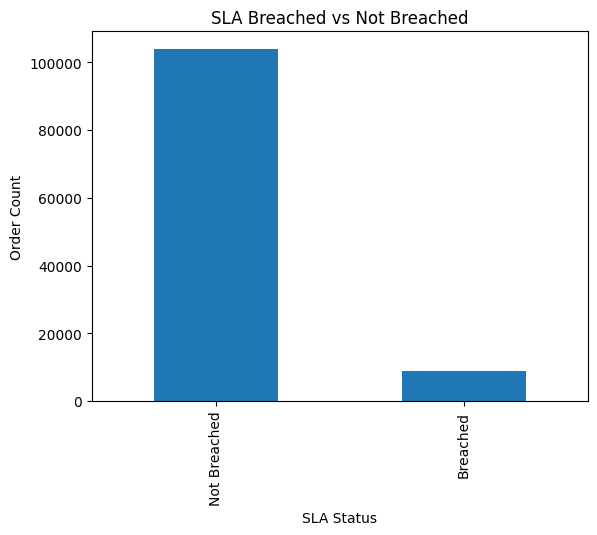

In [45]:
sla_labels = {
    0: 'Not Breached',
    1: 'Breached'
}

df['sla_breached'].map(sla_labels).value_counts().plot(kind='bar')

plt.title('SLA Breached vs Not Breached')
plt.xlabel('SLA Status')
plt.ylabel('Order Count')

plt.show()

## SLA Breach Rate by Customer State

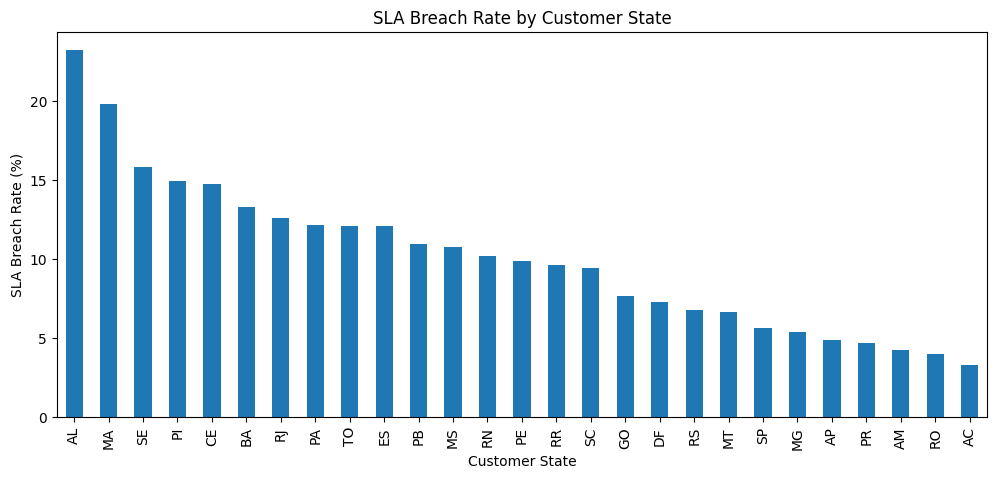

In [47]:
(
    df.groupby('customer_state')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).plot(kind='bar', figsize=(12,5))

plt.title('SLA Breach Rate by Customer State')
plt.xlabel('Customer State')
plt.ylabel('SLA Breach Rate (%)')

plt.show()

## SLA Breach Rate by Seller State

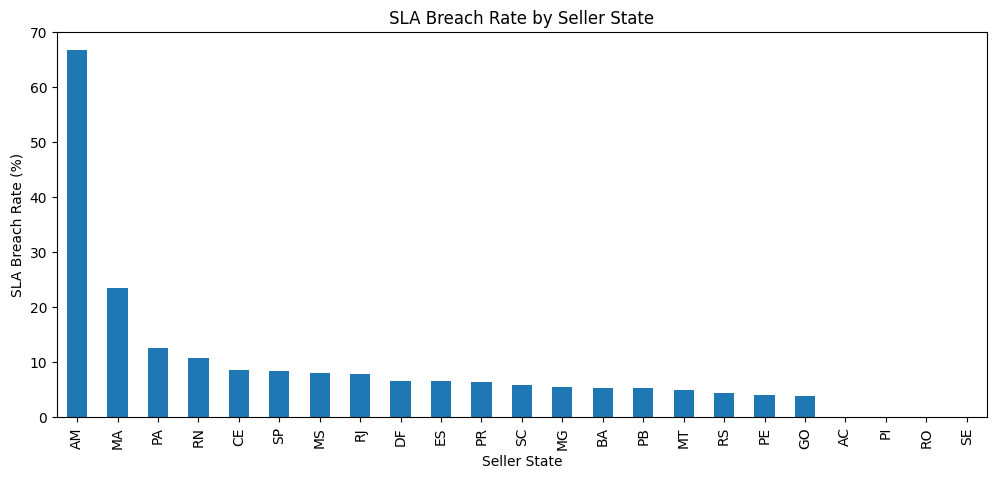

In [36]:
(
    df.groupby('seller_state')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).plot(kind='bar', figsize=(12,5))

plt.title('SLA Breach Rate by Seller State')
plt.xlabel('Seller State')
plt.ylabel('SLA Breach Rate (%)')

plt.show()

## SLA Breach Rate by Purchase Day

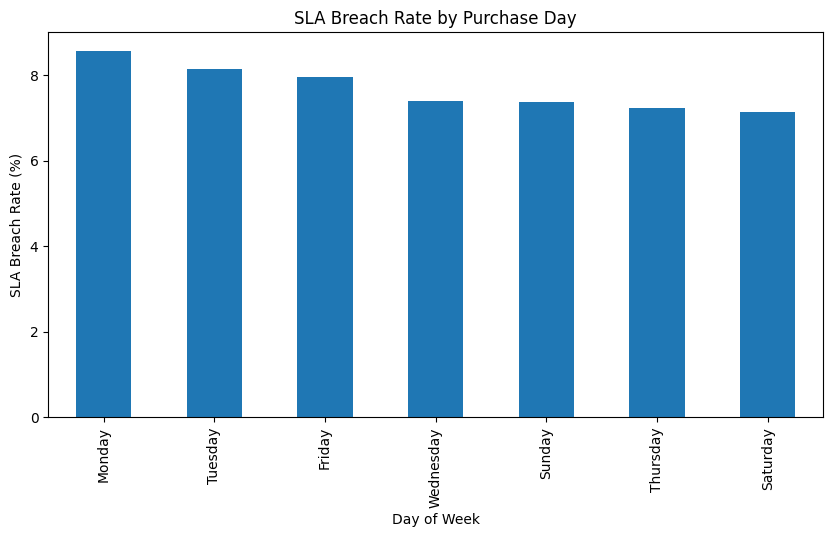

In [37]:
(
    df.groupby('purchase_day')['sla_breached']
    .mean()
    .sort_values(ascending=False) * 100
).plot(kind='bar', figsize=(10,5))

plt.title('SLA Breach Rate by Purchase Day')
plt.xlabel('Day of Week')
plt.ylabel('SLA Breach Rate (%)')

plt.show()

## Top 10 Product Categories by SLA Breach Rate

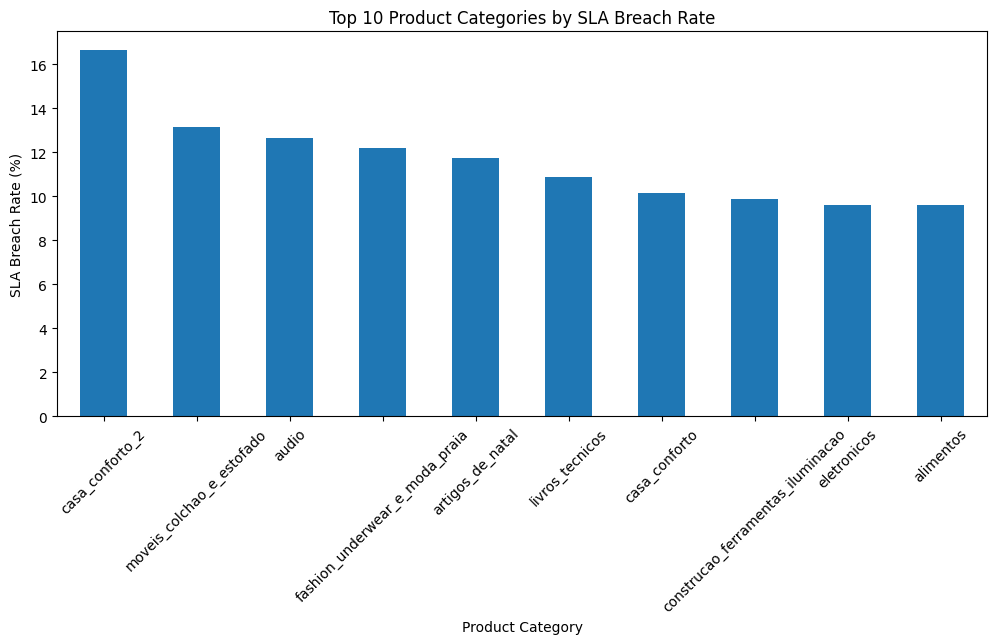

In [38]:
(
    df.groupby('product_category_name')['sla_breached']
    .mean()
    .sort_values(ascending=False)
    .head(10) * 100
).plot(kind='bar', figsize=(12,5))

plt.title('Top 10 Product Categories by SLA Breach Rate')
plt.xlabel('Product Category')
plt.ylabel('SLA Breach Rate (%)')

plt.xticks(rotation=45)

plt.show()